## This was the best accuracy so far but the loss was trash
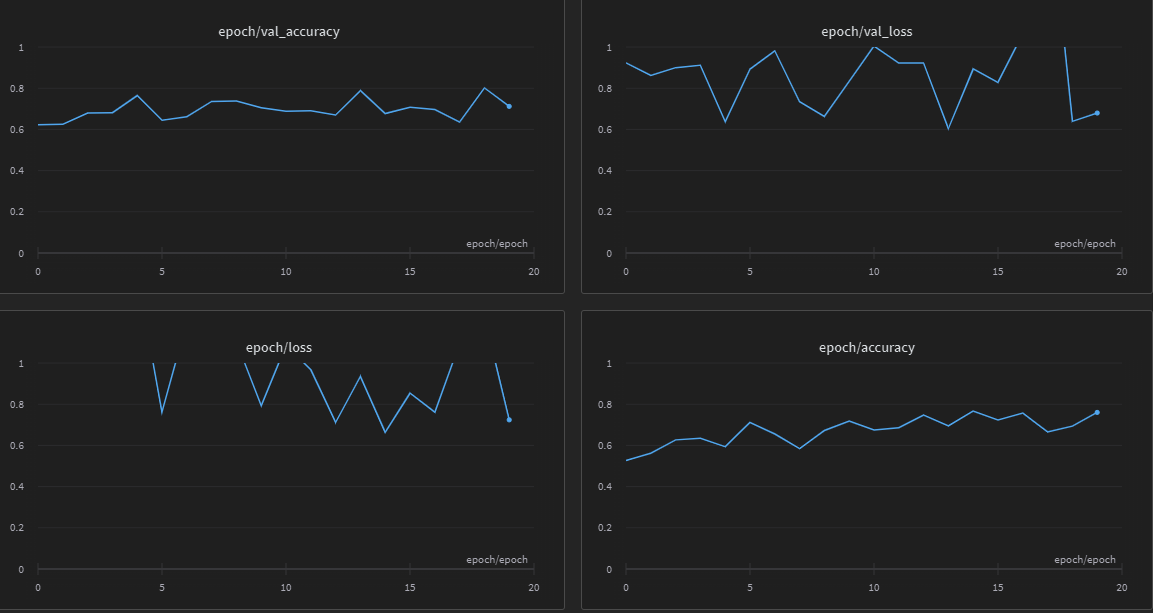

In [1]:
import os
import numpy as np
import pandas as pd
import cv2

# import splitfolders
import h5py
from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rcParams
import seaborn as sns
from PIL import Image
import imutils 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.applications import (
    InceptionResNetV2,
    ResNet50,
    InceptionV3,
    DenseNet121,
)
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import classification_report, confusion_matrix



In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)
    google_drive_prefix = "/content/drive/My Drive"
    data_prefix = "{}/mnist/".format(google_drive_prefix)
except ModuleNotFoundError: 
    data_prefix = "data/"

Mounted at /content/drive/


In [4]:
!pip install wandb

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [5]:
import wandb
wandb.login()

ERROR:wandb.jupyter:Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: fleur. Use `wandb login --relogin` to force relogin


True

In [6]:
from wandb.keras import WandbMetricsLogger, WandbModelCheckpoint

In [89]:
# Start a run, tracking hyperparameters
wandb.init(
    # set the wandb project where this run will be logged
    project="Mermoire_2023_Version_01",

    # track hyperparameters and run metadata with wandb.config
    config={
        "dropout": 0.5,
        "dropout_2": 0.2,
        "activation_1": "relu",
        "activation_2": "softmax",
        "optimizer": "Adam",
        "loss": "categorical_crossentropy",
        "metric": "accuracy",
        "epoch": 20,
        "batch_size": 32,
        "units_1": 128,
        "learning_rate": 0.01
    }
)

In [90]:
config = wandb.config

In [79]:
train_set = '/content/drive/My Drive/Datasets/Cropped_Image_Sets/train/'
val_set = '/content/drive/My Drive/Datasets/Cropped_Image_Sets/val/'
test_set = '/content/drive/My Drive/Datasets/Cropped_Image_Sets/test/'
augmented_set = '/content/drive/My Drive/Datasets/Augmented/'
# model_dir ="/content/drive/My Drive/Models/RadImageNet-DenseNet121_notop.h5"
model_dir ="/content/drive/My Drive/Models/RadImageNet-ResNet50_notop.h5"
IMAGE_SIZE = 128

In [80]:
def init_data(train_dir: str, valid_dir: str, test_dir: str) -> list:
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale = 1/255.0,
        horizontal_flip = True,
        vertical_flip = True,
        width_shift_range = .1,
        height_shift_range = 0.1,
        # shear_range = 0.2,
        # rotation_range = 5,
        zoom_range = [0.8, 1]
    )
    valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1/255.0
    )
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1/255.0
    )
    
    train_data = train_datagen.flow_from_directory(
        directory=train_dir,
        save_to_dir=augmented_set,
        classes=['glioma_cropped', 'meningioma_cropped', 'pituitary_tumor_cropped'],
        class_mode='categorical',
        target_size=(128, 128),
        batch_size=32,
        seed=42,
        shuffle=False,
    )
    valid_data = valid_datagen.flow_from_directory(
        directory=valid_dir,
        save_to_dir=augmented_set,
        classes=['glioma_cropped', 'meningioma_cropped', 'pituitary_tumor_cropped'],
        class_mode='categorical',
        target_size=(128, 128),
        batch_size=32,
        seed=42,
        shuffle=False,
    )
    
    test_data = test_datagen.flow_from_directory(
        directory=test_dir,
        save_to_dir=augmented_set,
        classes=['glioma_cropped', 'meningioma_cropped', 'pituitary_tumor_cropped'],
        class_mode='categorical',
        target_size=(128, 128),
        batch_size=32,
        seed=42,
        shuffle=False,
    )
    
    return train_data, valid_data, test_data

In [81]:
train_data, valid_data, test_data = init_data(train_dir=train_set, valid_dir=val_set, test_dir=test_set)

Found 2144 images belonging to 3 classes.
Found 458 images belonging to 3 classes.
Found 472 images belonging to 3 classes.


In [24]:
n_samples_train = len(train_data)*(config.batch_size)
print("Number of samples in the training set: ",n_samples_train)

n_samples_val = len(valid_data)*(config.batch_size)
print("Number of samples in the training set: ",n_samples_val)

n_samples_test = len(test_data)*(config.batch_size)
print("Number of samples in the training set: ",n_samples_test)

Number of samples in the training set:  2144
Number of samples in the training set:  480
Number of samples in the training set:  480


In [13]:
model_name = "My_model"

TensorBoard = TensorBoard(log_dir="logs\\{}".format(model_name))

In [91]:
def build_transfer_learning_model(base_model):
    # `base_model` stands for the pretrained model
    # We want to use the learned weights, and to do so we must freeze them
    for layer in base_model.layers:
        layer.trainable = False
        
    # Declare a sequential model that combines the base model with custom layers
    model = tf.keras.Sequential([
        base_model,
        # tf.keras.layers.Flatten(),
        # tf.keras.layers.GlobalAveragePooling2D(),
        # tf.keras.layers.Dropout(rate=config.dropout),
        # tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Dense(config.units_1, activation=config.activation_1),
        tf.keras.layers.Dropout(rate=config.dropout_2),
        tf.keras.layers.Dense(units=3, activation=config.activation_2)
    ])
    
    # Compile the model
    model.compile(
        loss=config.loss,
        optimizer=Adam(learning_rate=config.learning_rate),
        metrics=[config.metric]
    )
    
    return model

In [ ]:
# rad_model = build_transfer_learning_model(
#     base_model = ResNet50(weights= model_dir, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),  include_top=False, pooling="avg")
# )
rad_model = build_transfer_learning_model(
    base_model = ResNet50(weights= model_dir, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),  include_top=False, pooling="avg")
)

In [ ]:
rad_model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dropout_10 (Dropout)        (None, 2048)              0         
                                                                 
 dense_10 (Dense)            (None, 3)                 6147      
                                                                 
Total params: 23,593,859
Trainable params: 6,147
Non-trainable params: 23,587,712
_________________________________________________________________


In [ ]:
# Train the model for 10 epochs
rad_hist = rad_model.fit(
    train_data,
    validation_data=valid_data,
    steps_per_epoch= n_samples_train/config.batch_size,
    epochs=config.epoch,
    callbacks= [TensorBoard,
                WandbMetricsLogger(log_freq=5),
                WandbModelCheckpoint("models"),
                ]
)
wandb.finish()

In [86]:
path = "/content/drive/My Drive/Models/"
saved_model = path + "model_02" + "_config.dropout_2" + "_config.learning_rate" + "_config.batch_size" + "_" + config.optimizer + ".h5"
print("Saving: ", saved_model)
rad_model.save(path)

Saving:  /content/drive/My Drive/Models/model_02_config.dropout_2_config.learning_rate_config.batch_size_Adam.h5


In [87]:
print("Evaluate on test data")
results = rad_model.evaluate(test_data, batch_size=32)
print("test loss, test acc:", results)

Evaluate on test data
15/15 [==============================] - 45s 3s/step - loss: 0.8326 - accuracy: 0.5699
test loss, test acc: [0.8325894474983215, 0.569915235042572]


In [88]:
Y_pred = rad_model.predict(valid_data, n_samples_val // config.batch_size+1)
y_pred = np.argmax(Y_pred, axis=1)
print('Confusion Matrix')
print(confusion_matrix(valid_data.classes, y_pred))
print('Classification Report')
target_names = ['glioma', 'meningioma', 'pituitary']
print(classification_report(valid_data.classes, y_pred, target_names=target_names))

15/15 [==============================] - 40s 3s/step
Confusion Matrix
[[205   8   0]
 [ 70  34   2]
 [112  14  13]]
Classification Report
              precision    recall  f1-score   support

      glioma       0.53      0.96      0.68       213
  meningioma       0.61      0.32      0.42       106
   pituitary       0.87      0.09      0.17       139

    accuracy                           0.55       458
   macro avg       0.67      0.46      0.42       458
weighted avg       0.65      0.55      0.47       458

